创建老虎机

In [12]:
import numpy as np
import matplotlib.pyplot as plt


class BernoulliBandit:
    """ 
        伯努利多臂老虎机生成
    """
    def __init__(self, K):
        """
            多臂老虎机初始化
            K：生成一个K个臂的老虎机
        """
        self.probs = np.random.uniform(size=K)  # 随机生成 K 个0～1的数,作为拉动每根拉杆的获奖
        # 概率
        self.best_idx = np.argmax(self.probs)       # 获奖概率最大的拉杆的索引 
        self.best_prob = self.probs[self.best_idx]  # 最大的获奖概率
        self.K = K

    def step(self, n):
        """
            指定选择老虎机的某一个臂
            n：老虎机拉杆的编号
        """
        # 当玩家选择了k号拉杆后,根据拉动该老虎机的k号拉杆获得奖励的概率返回1（获奖）或0（未获奖）
        if np.random.rand() < self.probs[n]:
            return 1
        else:
            return 0


np.random.seed(1)    # 设定随机种子,使实验具有可重复性，每次产生一样的随机数
K = 10
bandit_10_arm = BernoulliBandit(K)
print("随机生成了一个%d臂伯努利老虎机" % K)
print("获奖概率最大的拉杆为%d号,其获奖概率为%.4f" %
        (bandit_10_arm.best_idx, bandit_10_arm.best_prob))


随机生成了一个10臂伯努利老虎机
获奖概率最大的拉杆为1号,其获奖概率为0.7203


算法实现

In [14]:
class Solver:
    """ 
        多臂老虎机算法基本框架 
    """
    def __init__(self, bandit):
        """
            bandit：老虎机环境对象（创建的老虎机对象）
        """
        self.bandit = bandit
        self.counts = np.zeros(self.bandit.K)  # 每根拉杆的尝试次数
        self.regret = 0.   # 当前步的累积懊悔
        self.actions = []  # 维护一个列表,记录每一步的动作
        self.regrets = []  # 维护一个列表,记录每一步的累积懊悔

    def update_regret(self, n):
        """
            计算累积懊悔并保存
            n：为本次动作选择的拉杆的编号
        """
        self.regret += self.bandit.best_prob - self.bandit.probs[n]
        self.regrets.append(self.regret)

    def run_one_step(self):
        """
            返回当前动作选择哪一根拉杆,由每个具体的策略实现
        """ 
        raise NotImplementedError

    def run(self, num_steps):
        """
            运行
            num_steps：为总运行次数
        """
        for _ in range(num_steps):
            k = self.run_one_step()         # 执行单步操作，并获得拉杆编号
            self.counts[k] += 1             # 相应动作执行次数+1
            self.actions.append(k)          # 记录当前动作
            self.update_regret(k)           # 更新累积懊悔并记录

ϵ-贪心算法

In [15]:
class EpsilonGreedy(Solver):
    """ 
        epsilon贪婪算法,继承Solver类 
    """
    def __init__(self, bandit, epsilon=0.01, init_prob=1.0):
        """
            bandit：老虎机环境对象
            epsilon：ϵ，探索的概率
            init_prob：初始期望
        """
        super(EpsilonGreedy, self).__init__(bandit)
        self.epsilon = epsilon
        self.estimates = np.array([init_prob] * self.bandit.K)          #初始化拉动所有拉杆的期望奖励估值

    def run_one_step(self):
        """
            执行一步动作
        """
        # 执行 探索
        if np.random.random() < self.epsilon:
            n = np.random.randint(0, self.bandit.K)            # 随机选择一根拉杆
        # 执行 利用
        else:
            n = np.argmax(self.estimates)                      # 选择期望奖励估值最大的拉杆
        
        r = self.bandit.step(n)  # 与环境交互得到本次动作的奖励
        self.estimates[n] += 1. / (self.counts[n] + 1) * (r - self.estimates[n])           # 根据公式计算当前期望
        return n


绘图展示

In [16]:
def plot_results(solvers, solver_names):
    """
        生成累积懊悔随时间变化的图像。输入solvers是一个列表,列表中的每个元素是一种特定的策略。
        而solver_names也是一个列表,存储每个策略的名称
    """
    for idx, solver in enumerate(solvers):
        time_list = range(len(solver.regrets))
        plt.plot(time_list, solver.regrets, label=solver_names[idx])
    plt.xlabel('Time steps')
    plt.ylabel('Cumulative regrets')
    plt.title('%d-armed bandit' % solvers[0].bandit.K)
    plt.legend()
    plt.show()

执行试试（ϵ=0.01,T=5000）

epsilon-贪婪算法的累积懊悔为： 25.526630933945313


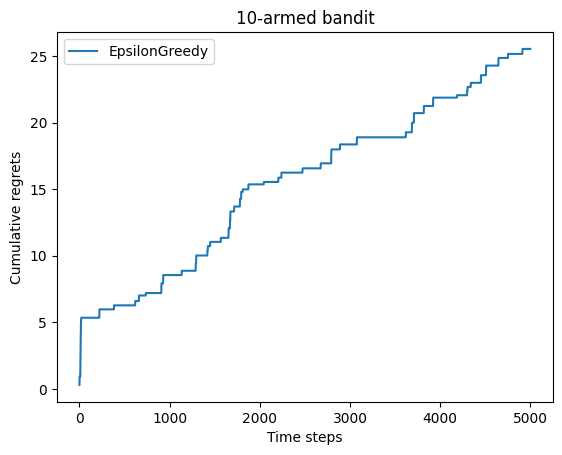

In [17]:
np.random.seed(1)
# 创建算法实现对象
epsilon_greedy_solver = EpsilonGreedy(bandit_10_arm, epsilon=0.01)
epsilon_greedy_solver.run(5000)
print('epsilon-贪婪算法的累积懊悔为：', epsilon_greedy_solver.regret)
plot_results([epsilon_greedy_solver], ["EpsilonGreedy"])


可以看出在经历了开始的一小段时间后，ϵ-贪婪算法的累积懊悔几乎是线性增长的，这是 ϵ=0.01 时的效果，可以看一下如果我们增大探索的力度，即增大ϵ，会发生什么：

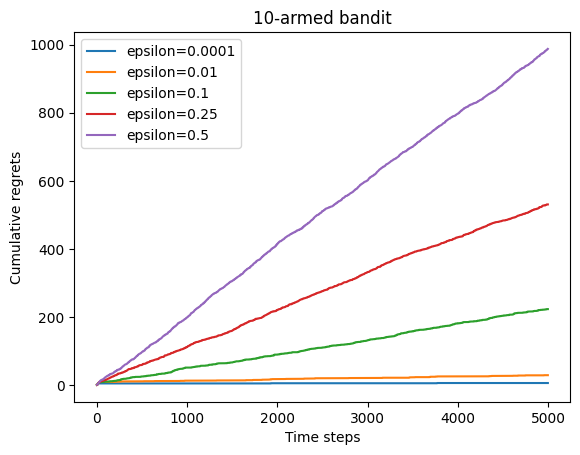

In [18]:
np.random.seed(0)
epsilons = [1e-4, 0.01, 0.1, 0.25, 0.5]
epsilon_greedy_solver_list = [
    EpsilonGreedy(bandit_10_arm, epsilon=e) for e in epsilons
]
epsilon_greedy_solver_names = ["epsilon={}".format(e) for e in epsilons]
for solver in epsilon_greedy_solver_list:
    solver.run(5000)

plot_results(epsilon_greedy_solver_list, epsilon_greedy_solver_names)

通过实验结果可以发现，基本上无论 ϵ 取值多少，累积懊悔都是线性增长的。在这个例子中，随着 ϵ 的增大，累积懊悔增长的速率也会增大。 接下来我们尝试 ϵ 值随时间衰减的 ϵ-贪婪算法，采取的具体衰减形式为反比例衰减，公式为 $\frac{1}{ϵ}$

epsilon值衰减的贪婪算法的累积懊悔为： 10.114334931260183


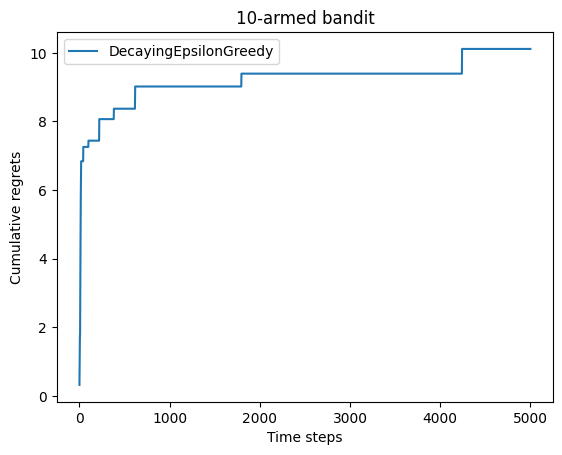

In [20]:
class DecayingEpsilonGreedy(Solver):
    """ 
        epsilon值随时间衰减的epsilon-贪婪算法,继承Solver类 
    """
    def __init__(self, bandit, init_prob=1.0):
        """
            bandit：多臂老虎机对象
            init_prob：初始期望
        """
        super(DecayingEpsilonGreedy, self).__init__(bandit)
        self.estimates = np.array([init_prob] * self.bandit.K)
        self.total_count = 0

    def run_one_step(self):
        self.total_count += 1
        # 一开始探索比较强，越到后面我们利用就越强；
        if np.random.random() < 1 / self.total_count:  # epsilon值随时间衰减
            k = np.random.randint(0, self.bandit.K)
        else:
            k = np.argmax(self.estimates)

        r = self.bandit.step(k)
        self.estimates[k] += 1. / (self.counts[k] + 1) * (r - self.estimates[k])

        return k


np.random.seed(1)
decaying_epsilon_greedy_solver = DecayingEpsilonGreedy(bandit_10_arm)
decaying_epsilon_greedy_solver.run(5000)
print('epsilon值衰减的贪婪算法的累积懊悔为：', decaying_epsilon_greedy_solver.regret)
plot_results([decaying_epsilon_greedy_solver], ["DecayingEpsilonGreedy"])